### **Chain**

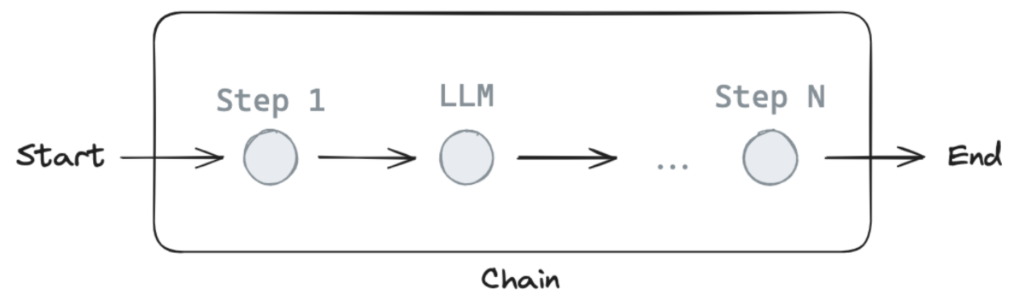

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph

#### **Messages**
Chat models can use `messages`, which capture different roles within a conversation. LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Each message can be supplied with a few things:
- `content` - content of the message
- `name` - optionally, a message author
- `response_metadata` - optionally, a dict of metadata

In [1]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [
    AIMessage(content = 'So you said you were researching ocean mammals?', name = 'Model'),
    HumanMessage(content = 'Yes, that\'s right.', name='Lance')
]
messages.append(AIMessage(content = 'Great, what would you like to learn about.', name = 'Model'))
messages.append(HumanMessage(content='I want to learn about the best place to see Orcas in the US.', name = 'Lance'))

for m in messages:
    m.pretty_print() # Cant run m.pprint() because no pprint method supports

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


#### **Chat Models**

In [2]:
import os, openai
from dotenv import load_dotenv, find_dotenv

_ = load_dotenv(find_dotenv())
openai.api_key = os.environ['OPENAI_API_KEY']

llm_model = 'gpt-4o'

In [4]:
from langchain_openai import ChatOpenAI

chat = ChatOpenAI(temperature = 0, model = llm_model)
response = chat.invoke(messages)

#### **Tools**
Tools are essential for enabling language models to interact with external systems. External systems (API, etc..) typically require specific input formats, rather than plain natural language. By binding an API or function as a tool, we inform the model of the expected input schema. The language model can then decide when to invoke a tool based on the user’s natural language input, and it will produce outputs that conform to the tool’s schema.

Most major LLM providers now support tool calling, and LangChain provides a straightforward interface—any Python function can be passed directly into ChatModel.bind_tools() to expose it as a tool for the model.

![Binding tool to LLM.png](<attachment:Binding tool to LLM.png>)
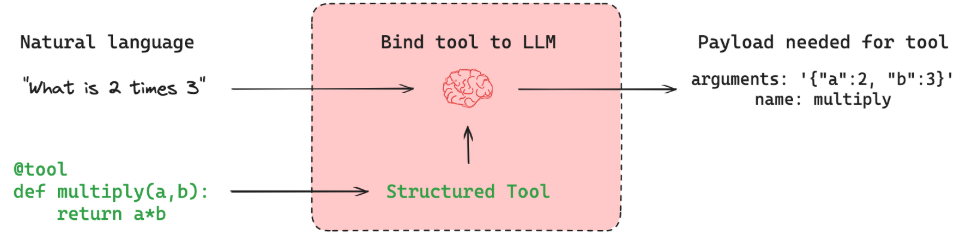

In [5]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = chat.bind_tools([multiply])
tool_call = llm_with_tools.invoke([HumanMessage(content = f'What is 2 multiplied by 3', name = 'Lance')])
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_gYL7nLqXiCzdK4p2mOpjCC1o',
  'type': 'tool_call'}]

#### **Reducers**
Reducers let us control how state updates occur. Without a reducer, updates will overwrite the existing value.

To append new messages instead, use the built-in `add_messages` reducer by annotating the `graph_state` key, which ensures new entries are added to the existing list.

In [ ]:
# Without reducers
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    # Does not specify how updates to the list should be handled. Thus, new graph_state will overwrite whatever was there
    graph_state: list[AnyMessage] 

In [21]:
# With reducers
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    graph_state: Annotated[list[AnyMessage], add_messages]

In [ ]:
# 'add_messages' demonstration
# Initial state
initial_messages = [
    AIMessage(content = 'Hello! How can I assist you?', name = 'Model'),
    HumanMessage(content = 'I\'m looking for information on marine biology.', name = 'Lance')
]

# New message to add
new_message = AIMessage(content = 'Sure, I can help with that. What specifically are you interested in?', name = 'Model')

# Test
add_messages(initial_messages , new_message)

LangGraph has a pre-built MessagesState:
- With a pre-build single `graph_state` key
- With list of `AnyMessage` objects
- Uses the `add_messages` reducer

In [25]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

#### **Graph**

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))